<a href="https://colab.research.google.com/github/Hansen256/NLP_coursework_1/blob/main/notebooks/group1_hybrid_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install dependencies not pre-installed on Colab
!pip install kagglehub gensim sentence-transformers transformers -q
!pip install "spacy>=3.7,<3.9" -q
!python -m spacy download en_core_web_sm -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 120.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
# Upload Kaggle API credentials (kaggle.json) — required on Colab
import os
import shutil

if not os.path.exists(os.path.expanduser('~/.kaggle/kaggle.json')):
    from google.colab import files
    print('Please upload your kaggle.json file:')
    uploaded = files.upload()
    os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
    # shutil.move handles cross-device moves (os.rename fails across filesystems on Colab)
    shutil.move('kaggle.json', os.path.expanduser('~/.kaggle/kaggle.json'))
    os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)
    print('Kaggle credentials configured.')
else:
    print('Kaggle credentials already present, skipping upload.')


Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Kaggle credentials configured.


# Group 1: Social Media Text Preprocessing (Hybrid NLP)

This notebook implements the coursework tasks for:
- Dataset A (English): Sentiment140
- Dataset B (African language): Swahili Tweets

Pipelines used for each dataset:
1. Rule-based cleaning
2. Statistical normalization (TF-IDF + entropy stop-word filtering)
3. Deep normalization (spaCy NER-aware lemmatization for English, transformer-aware preprocessing for Swahili)

## 0) Setup Steps
1. Run the first cell to install `kagglehub`.
2. Run the second cell to upload your `kaggle.json` credentials file (download it from **kaggle.com → Account → API → Create New Token**).
3. Run all remaining cells top-to-bottom — datasets are downloaded automatically from Kaggle.

In [3]:
import os
import re
import glob
import random
import warnings
from collections import Counter, defaultdict

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

warnings.filterwarnings('ignore')
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
sns.set(style='whitegrid')

PROJECT_ROOT_DIRECTORY = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
RAW_DATA_DIRECTORY = os.path.join(PROJECT_ROOT_DIRECTORY, 'data', 'raw')
PROCESSED_DATA_DIRECTORY = os.path.join(PROJECT_ROOT_DIRECTORY, 'data', 'processed')
REPORT_OUTPUT_DIRECTORY = os.path.join(PROJECT_ROOT_DIRECTORY, 'reports')
FIGURE_OUTPUT_DIRECTORY = os.path.join(REPORT_OUTPUT_DIRECTORY, 'figures')

for directory_path in [RAW_DATA_DIRECTORY, PROCESSED_DATA_DIRECTORY, REPORT_OUTPUT_DIRECTORY, FIGURE_OUTPUT_DIRECTORY]:
    os.makedirs(directory_path, exist_ok=True)

print('PROJECT_ROOT_DIRECTORY:', PROJECT_ROOT_DIRECTORY)
print('RAW_DATA_DIRECTORY:', RAW_DATA_DIRECTORY)

PROJECT_ROOT_DIRECTORY: /content
RAW_DATA_DIRECTORY: /content/data/raw


In [ ]:
# ── Google Drive output──────────────────────────────────────────
# Set USE_GOOGLE_DRIVE = True to persist all outputs to your Drive.
# Files will be saved under: My Drive / nlp_coursework_1 / ...
# This is the recommended option for Colab — files survive runtime resets.
USE_GOOGLE_DRIVE = True

if USE_GOOGLE_DRIVE:
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        _drive_root = '/content/drive/MyDrive/nlp_coursework_1'
        PROCESSED_DATA_DIRECTORY = os.path.join(_drive_root, 'data', 'processed')
        REPORT_OUTPUT_DIRECTORY  = os.path.join(_drive_root, 'reports')
        FIGURE_OUTPUT_DIRECTORY  = os.path.join(_drive_root, 'reports', 'figures')
        for _dir in [PROCESSED_DATA_DIRECTORY, REPORT_OUTPUT_DIRECTORY, FIGURE_OUTPUT_DIRECTORY]:
            os.makedirs(_dir, exist_ok=True)
        print('✓ Outputs redirected to Google Drive:', _drive_root)
    except Exception as _e:
        print(f'Google Drive mount skipped ({_e}). Falling back to local paths.')
else:
    print('Google Drive disabled — outputs saved to local Colab filesystem (lost on disconnect).')


In [4]:
# Download datasets from Kaggle via kagglehub
# Kaggle API credentials must be set up in the environment (e.g. via kaggle.json or KAGGLE_USERNAME/KAGGLE_KEY env vars)
_english_dataset_dir = kagglehub.dataset_download('kazanova/sentiment140')
_swahili_dataset_dir = kagglehub.dataset_download('waalbannyantudre/swahili-news-classification-dataset')

# Resolve the actual CSV file paths within the downloaded directories
def _find_csv(directory, preferred_name=None):
    """Return the path to a CSV file inside `directory`, preferring `preferred_name` if given."""
    if preferred_name:
        candidate = os.path.join(directory, preferred_name)
        if os.path.exists(candidate):
            return candidate
    matches = glob.glob(os.path.join(directory, '**', '*.csv'), recursive=True)
    if not matches:
        raise FileNotFoundError(f'No CSV files found in {directory}')
    return sorted(matches)[0]

DATASET_FILE_PATHS = {
    'english': _find_csv(_english_dataset_dir, preferred_name='training.1600000.processed.noemoticon.csv'),
    'swahili': _find_csv(_swahili_dataset_dir, preferred_name='train.csv'),
}

for dataset_name, dataset_path in DATASET_FILE_PATHS.items():
    print(dataset_name, '->', dataset_path, 'exists:', os.path.exists(dataset_path))

Using Colab cache for faster access to the 'sentiment140' dataset.


100%|██████████| 18.1M/18.1M [00:00<00:00, 129MB/s] 

Extracting files...


english -> /kaggle/input/sentiment140/training.1600000.processed.noemoticon.csv exists: True
swahili -> /root/.cache/kagglehub/datasets/waalbannyantudre/swahili-news-classification-dataset/versions/1/SwahiliNewsClassificationDataset.csv exists: True


In [5]:
import spacy
from transformers import AutoTokenizer, pipeline

try:
    ENGLISH_SPACY_PIPELINE = spacy.load('en_core_web_sm')
except Exception:
    from spacy.cli import download
    download('en_core_web_sm')
    ENGLISH_SPACY_PIPELINE = spacy.load('en_core_web_sm')

MULTILINGUAL_ROBERTA_TOKENIZER = AutoTokenizer.from_pretrained('xlm-roberta-base')

SWAHILI_NER_PIPELINE = None
try:
    SWAHILI_NER_PIPELINE = pipeline(
        'token-classification',
        model='Davlan/xlm-roberta-base-ner-hrl',
        aggregation_strategy='simple'
    )
except Exception:
    print('Swahili NER model unavailable, continuing without Swahili NER masking.')

print('Language models loaded.')

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/980 [00:00<?, ?B/s]

...

XLMRobertaForTokenClassification LOAD REPORT from: Davlan/xlm-roberta-base-ner-hrl
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/211 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Language models loaded.


In [ ]:
TEXT_COLUMN_CANDIDATES = ['text', 'tweet', 'content', 'message', 'sentence']
LABEL_COLUMN_CANDIDATES = ['label', 'sentiment', 'class', 'target']

def detect_column(dataframe, candidate_columns, prefer_text_column=False):
    lowercase_to_original_column = {column_name.lower(): column_name for column_name in dataframe.columns}
    for candidate_column in candidate_columns:
        if candidate_column in lowercase_to_original_column:
            return lowercase_to_original_column[candidate_column]

    if prefer_text_column:
        object_columns = [column_name for column_name in dataframe.columns if str(dataframe[column_name].dtype) == 'object']
        if object_columns:
            average_text_length_by_column = {
                column_name: dataframe[column_name].astype(str).str.len().mean()
                for column_name in object_columns
            }
            return max(average_text_length_by_column, key=average_text_length_by_column.get)

    low_cardinality_columns = [column_name for column_name in dataframe.columns if dataframe[column_name].nunique(dropna=True) <= 20]
    return low_cardinality_columns[0] if low_cardinality_columns else None

def load_sentiment140(csv_path):
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f'Missing file: {csv_path}')

    try:
        sentiment_dataframe = pd.read_csv(csv_path, encoding='ISO-8859-1', header=None)
        if sentiment_dataframe.shape[1] < 6:
            # Not the standard Sentiment140 layout — fall through to generic loader
            raise ValueError(f'Unexpected Sentiment140 shape: {sentiment_dataframe.shape[1]} columns')
        sentiment_dataframe = sentiment_dataframe.iloc[:, :6]
        sentiment_dataframe.columns = ['sentiment', 'tweet_id', 'date', 'query', 'user_name', 'text']
    except (pd.errors.ParserError, UnicodeDecodeError, ValueError):
        sentiment_dataframe = pd.read_csv(csv_path)
        detected_text_column = detect_column(sentiment_dataframe, TEXT_COLUMN_CANDIDATES, prefer_text_column=True)
        detected_label_column = detect_column(sentiment_dataframe, LABEL_COLUMN_CANDIDATES, prefer_text_column=False)

        if detected_text_column is None:
            raise ValueError('Could not detect text column for Sentiment140')

        if detected_label_column is None:
            detected_label_column = 'sentiment'
            sentiment_dataframe[detected_label_column] = np.nan

        sentiment_dataframe = sentiment_dataframe.rename(
            columns={detected_text_column: 'text', detected_label_column: 'sentiment'}
        )

    sentiment_dataframe = sentiment_dataframe[['text', 'sentiment']].copy()
    sentiment_dataframe['text'] = sentiment_dataframe['text'].astype(str)
    sentiment_dataframe['sentiment'] = sentiment_dataframe['sentiment'].astype(str)
    return sentiment_dataframe

def load_generic_dataset(csv_path, dataset_name='dataset'):
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f'Missing file: {csv_path}')

    generic_dataframe = pd.read_csv(csv_path)
    detected_text_column = detect_column(generic_dataframe, TEXT_COLUMN_CANDIDATES, prefer_text_column=True)
    detected_label_column = detect_column(generic_dataframe, LABEL_COLUMN_CANDIDATES, prefer_text_column=False)

    if detected_text_column is None:
        raise ValueError(f'Could not detect text column for {dataset_name}')

    if detected_label_column is None:
        detected_label_column = 'sentiment'
        generic_dataframe[detected_label_column] = np.nan

    prepared_dataframe = generic_dataframe.rename(
        columns={detected_text_column: 'text', detected_label_column: 'sentiment'}
    )[['text', 'sentiment']].copy()
    prepared_dataframe['text'] = prepared_dataframe['text'].astype(str)
    prepared_dataframe['sentiment'] = prepared_dataframe['sentiment'].astype(str)
    return prepared_dataframe

english_dataframe = load_sentiment140(DATASET_FILE_PATHS['english'])
swahili_dataframe = load_generic_dataset(DATASET_FILE_PATHS['swahili'], dataset_name='swahili')

# --- Sampling ---
# Sentiment140 has 1.6 M rows; processing all of them would take hours.
# 50 k rows gives representative statistics and finishes in minutes on Colab.
SAMPLE_SIZE = 50_000
english_dataframe = (
    english_dataframe
    .sample(min(SAMPLE_SIZE, len(english_dataframe)), random_state=RANDOM_SEED)
    .reset_index(drop=True)
)
swahili_dataframe = (
    swahili_dataframe
    .sample(min(SAMPLE_SIZE, len(swahili_dataframe)), random_state=RANDOM_SEED)
    .reset_index(drop=True)
)

print('English shape (sampled):', english_dataframe.shape)
print('Swahili shape (sampled):', swahili_dataframe.shape)
english_dataframe.head()


English shape: (1600000, 2)
Swahili shape: (23268, 2)


,text,sentiment
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",0
1,is upset that he can't update his Facebook by ...,0
2,@Kenichan I dived many times for the ball. Man...,0
3,my whole body feels itchy and like its on fire,0
4,"@nationwideclass no, it's not behaving at all....",0


In [7]:
URL_PATTERN = re.compile(r'https?://\S+|www\.\S+')
MENTION_PATTERN = re.compile(r'@\w+')
HASHTAG_PATTERN = re.compile(r'#\w+')
NUMBER_PATTERN = re.compile(r'\b\d+\b')
REPEATED_CHARACTER_PATTERN = re.compile(r'(.)\1{2,}')
PUNCTUATION_BURST_PATTERN = re.compile(r'[!?.,]{2,}')
EMOJI_PATTERN = re.compile('[\U00010000-\U0010ffff]', flags=re.UNICODE)

def extract_noise_features(text_value):
    normalized_text = str(text_value)
    return {
        'has_url': int(bool(URL_PATTERN.search(normalized_text))),
        'has_mention': int(bool(MENTION_PATTERN.search(normalized_text))),
        'has_hashtag': int(bool(HASHTAG_PATTERN.search(normalized_text))),
        'has_number': int(bool(NUMBER_PATTERN.search(normalized_text))),
        'has_repeated_chars': int(bool(REPEATED_CHARACTER_PATTERN.search(normalized_text))),
        'has_punct_burst': int(bool(PUNCTUATION_BURST_PATTERN.search(normalized_text))),
        'has_emoji': int(bool(EMOJI_PATTERN.search(normalized_text))),
        'is_mixed_case': int(any(character.islower() for character in normalized_text) and any(character.isupper() for character in normalized_text)),
        'char_len': len(normalized_text),
        'token_len': len(normalized_text.split())
    }

def summarize_noise_features(dataframe, language_name):
    noise_feature_dataframe = pd.DataFrame([extract_noise_features(text_value) for text_value in dataframe['text'].fillna('')])
    noise_summary_row = noise_feature_dataframe.mean(numeric_only=True).to_frame(name=language_name).T
    return noise_feature_dataframe, noise_summary_row

english_noise_features, english_noise_summary = summarize_noise_features(english_dataframe, 'English')
swahili_noise_features, swahili_noise_summary = summarize_noise_features(swahili_dataframe, 'Swahili')
noise_summary = pd.concat([english_noise_summary, swahili_noise_summary])
noise_summary

,has_url,has_mention,has_hashtag,has_number,has_repeated_chars,has_punct_burst,has_emoji,is_mixed_case,char_len,token_len
English,0.047308,0.461558,0.022404,0.109044,0.277281,0.259585,0.000000,0.760853,74.090111,13.176151
Swahili,0.004513,0.022434,0.011905,0.837631,0.214544,0.032061,0.010229,0.999914,2217.417354,332.495831


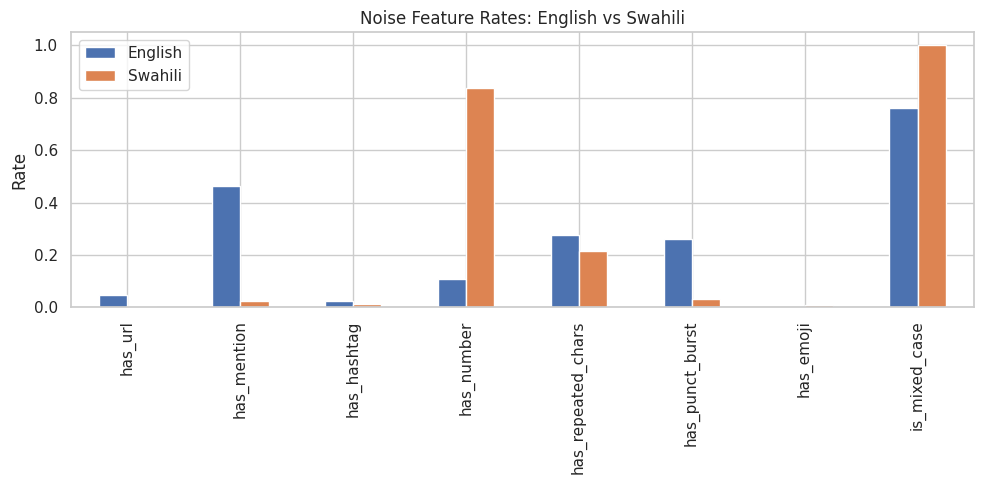

In [8]:
noise_metric_columns = [column_name for column_name in noise_summary.columns if column_name.startswith('has_') or column_name == 'is_mixed_case']
axis = noise_summary[noise_metric_columns].T.plot(kind='bar', figsize=(10, 5))
axis.set_title('Noise Feature Rates: English vs Swahili')
axis.set_ylabel('Rate')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_OUTPUT_DIRECTORY, 'noise_feature_rates.png'), dpi=200)
plt.show()

In [9]:
PUNCTUATION_PATTERN = re.compile(r'[^\w\s#@]')
MULTISPACE_PATTERN = re.compile(r'\s+')

def reduce_repeated_characters(text_value):
    return REPEATED_CHARACTER_PATTERN.sub(r'\1\1', text_value)

def clean_text_rule_based(text_value, keep_hashtag_text=True):
    cleaned_text = str(text_value)
    cleaned_text = URL_PATTERN.sub(' ', cleaned_text)
    cleaned_text = MENTION_PATTERN.sub(' ', cleaned_text)
    cleaned_text = EMOJI_PATTERN.sub(' ', cleaned_text)
    cleaned_text = reduce_repeated_characters(cleaned_text)
    cleaned_text = cleaned_text.lower()
    cleaned_text = NUMBER_PATTERN.sub(' ', cleaned_text)

    if keep_hashtag_text:
        cleaned_text = cleaned_text.replace('#', '')

    cleaned_text = PUNCTUATION_PATTERN.sub(' ', cleaned_text)
    cleaned_text = MULTISPACE_PATTERN.sub(' ', cleaned_text).strip()
    return cleaned_text

def tokenize_by_whitespace(text_value):
    return [token_value for token_value in str(text_value).split() if token_value.strip()]

def entropy_stopwords(tokenized_documents, min_document_frequency=5, top_entropy_percentile=90):
    token_document_counts = defaultdict(Counter)
    document_frequency_by_token = Counter()

    for document_index, tokenized_document in enumerate(tokenized_documents):
        # Use set() only for document-frequency counting
        for token_value in set(tokenized_document):
            document_frequency_by_token[token_value] += 1
        # Use the full token list so per-doc counts reflect actual term frequencies
        for token_value in tokenized_document:
            token_document_counts[token_value][document_index] += 1

    normalized_entropy_by_token = {}
    for token_value, document_counter in token_document_counts.items():
        if document_frequency_by_token[token_value] < min_document_frequency:
            continue

        token_probabilities = np.array(list(document_counter.values()), dtype=float)
        token_probabilities = token_probabilities / token_probabilities.sum()
        entropy_value = -np.sum(token_probabilities * np.log(token_probabilities + 1e-12))
        normalized_entropy = entropy_value / np.log(len(document_counter) + 1e-12) if len(document_counter) > 1 else 0.0
        normalized_entropy_by_token[token_value] = normalized_entropy

    if not normalized_entropy_by_token:
        return set(), normalized_entropy_by_token

    entropy_threshold = np.percentile(list(normalized_entropy_by_token.values()), top_entropy_percentile)
    entropy_stopword_set = {
        token_value
        for token_value, entropy_score in normalized_entropy_by_token.items()
        if entropy_score >= entropy_threshold
    }
    return entropy_stopword_set, normalized_entropy_by_token

ENGLISH_BASE_STOPWORDS = {'the','a','an','is','are','to','and','of','in','for','on','it','this','that','with','as','at','be','was','were'}
SWAHILI_BASE_STOPWORDS = {'na','ya','kwa','ni','wa','za','katika','la','ku','si','hii','hiyo','yake','ao','sana'}

def statistical_normalize(text_values, language='english'):
    language_base_stopwords = ENGLISH_BASE_STOPWORDS if language == 'english' else SWAHILI_BASE_STOPWORDS
    rule_cleaned_texts = [clean_text_rule_based(text_value) for text_value in text_values]
    tokenized_documents = [tokenize_by_whitespace(cleaned_text) for cleaned_text in rule_cleaned_texts]

    entropy_stopword_set, entropy_scores = entropy_stopwords(tokenized_documents)
    combined_stopword_set = language_base_stopwords.union(entropy_stopword_set)

    normalized_documents = []
    for tokenized_document in tokenized_documents:
        filtered_tokens = [
            token_value
            for token_value in tokenized_document
            if token_value not in combined_stopword_set and len(token_value) > 1
        ]
        normalized_documents.append(' '.join(filtered_tokens))

    return normalized_documents, combined_stopword_set, entropy_scores


In [ ]:
def deep_normalize_english(text_value):
    rule_cleaned_text = clean_text_rule_based(text_value)
    parsed_document = ENGLISH_SPACY_PIPELINE(rule_cleaned_text)
    normalized_tokens = []

    for parsed_token in parsed_document:
        if parsed_token.is_space or parsed_token.is_punct:
            continue

        if parsed_token.ent_type_:
            normalized_tokens.append(f'ENT_{parsed_token.ent_type_}')
        else:
            lemma_value = parsed_token.lemma_.strip().lower()
            if lemma_value:
                normalized_tokens.append(lemma_value)

    return ' '.join(normalized_tokens)

def deep_normalize_swahili(text_value):
    rule_cleaned_text = clean_text_rule_based(text_value)
    tokenizer_pieces = MULTILINGUAL_ROBERTA_TOKENIZER.tokenize(rule_cleaned_text)
    merged_tokens = []

    for tokenizer_piece in tokenizer_pieces:
        if tokenizer_piece.startswith('▁'):
            merged_tokens.append(tokenizer_piece[1:])
        elif merged_tokens:
            merged_tokens[-1] += tokenizer_piece
        else:
            merged_tokens.append(tokenizer_piece)

    merged_tokens = [merged_token for merged_token in merged_tokens if merged_token and merged_token.isalnum()]

    if SWAHILI_NER_PIPELINE is not None and rule_cleaned_text.strip():
        try:
            swahili_entities = SWAHILI_NER_PIPELINE(rule_cleaned_text[:512])
            entity_surface_forms = {
                entity_item['word'].lower().replace(' ', '')
                for entity_item in swahili_entities
                if entity_item.get('entity_group')
            }
            merged_tokens = [
                'ENT' if merged_token.lower() in entity_surface_forms else merged_token
                for merged_token in merged_tokens
            ]
        except Exception:
            pass

    return ' '.join(merged_tokens)

def _batch_deep_normalize_english(rule_cleaned_texts, batch_size=256):
    """Run spaCy over all texts in one batched pass — ~20x faster than row-by-row."""
    deep_texts = []
    for doc in ENGLISH_SPACY_PIPELINE.pipe(rule_cleaned_texts, batch_size=batch_size):
        normalized_tokens = []
        for token in doc:
            if token.is_space or token.is_punct:
                continue
            if token.ent_type_:
                normalized_tokens.append(f'ENT_{token.ent_type_}')
            else:
                lemma_value = token.lemma_.strip().lower()
                if lemma_value:
                    normalized_tokens.append(lemma_value)
        deep_texts.append(' '.join(normalized_tokens))
    return deep_texts

def apply_preprocessing_pipelines(input_dataframe, language):
    processed_dataframe = input_dataframe.copy()
    processed_dataframe['clean_rule'] = processed_dataframe['text'].map(clean_text_rule_based)

    statistical_texts, statistical_stopwords, entropy_score_by_token = statistical_normalize(
        processed_dataframe['text'].tolist(),
        language=language
    )
    processed_dataframe['clean_stat'] = statistical_texts

    if language == 'english':
        # Batched spaCy inference — avoids per-row Python overhead
        processed_dataframe['clean_deep'] = _batch_deep_normalize_english(
            processed_dataframe['clean_rule'].tolist()
        )
    else:
        processed_dataframe['clean_deep'] = processed_dataframe['text'].map(deep_normalize_swahili)

    preprocessing_metadata = {
        'stat_stop_count': len(statistical_stopwords),
        'entropy_vocab_count': len(entropy_score_by_token)
    }
    return processed_dataframe, preprocessing_metadata

english_processed_dataframe, english_pipeline_metadata = apply_preprocessing_pipelines(english_dataframe, 'english')
swahili_processed_dataframe, swahili_pipeline_metadata = apply_preprocessing_pipelines(swahili_dataframe, 'swahili')

print('English metadata:', english_pipeline_metadata)
print('Swahili metadata:', swahili_pipeline_metadata)
english_processed_dataframe[['text', 'clean_rule', 'clean_stat', 'clean_deep']].head()


In [ ]:
def save_pipeline_outputs(processed_dataframe, dataset_prefix):
    base_columns = ['text', 'sentiment']

    rule_output_dataframe = processed_dataframe[base_columns + ['clean_rule']].rename(columns={'clean_rule': 'clean_text'})
    statistical_output_dataframe = processed_dataframe[base_columns + ['clean_stat']].rename(columns={'clean_stat': 'clean_text'})
    deep_output_dataframe = processed_dataframe[base_columns + ['clean_deep']].rename(columns={'clean_deep': 'clean_text'})

    rule_output_path = os.path.join(PROCESSED_DATA_DIRECTORY, f'{dataset_prefix}_rule.csv')
    statistical_output_path = os.path.join(PROCESSED_DATA_DIRECTORY, f'{dataset_prefix}_stat.csv')
    deep_output_path = os.path.join(PROCESSED_DATA_DIRECTORY, f'{dataset_prefix}_deep.csv')

    rule_output_dataframe.to_csv(rule_output_path, index=False)
    statistical_output_dataframe.to_csv(statistical_output_path, index=False)
    deep_output_dataframe.to_csv(deep_output_path, index=False)

    return [rule_output_path, statistical_output_path, deep_output_path]

english_output_paths = save_pipeline_outputs(english_processed_dataframe, 'english')
swahili_output_paths = save_pipeline_outputs(swahili_processed_dataframe, 'swahili')

print('Saved files:')
for output_path in english_output_paths + swahili_output_paths:
    print('-', output_path)

In [ ]:
def prepare_documents_for_topic_modeling(text_values, minimum_tokens=3):
    tokenized_documents = [tokenize_by_whitespace(text_value) for text_value in text_values]
    return [tokenized_document for tokenized_document in tokenized_documents if len(tokenized_document) >= minimum_tokens]

def compute_topic_diversity(topic_word_lists, top_n_words=10):
    all_topic_terms = []
    for topic_word_list in topic_word_lists:
        all_topic_terms.extend([term for term, _ in topic_word_list[:top_n_words]])
    return len(set(all_topic_terms)) / len(all_topic_terms) if all_topic_terms else 0.0

def compute_lda_metrics(text_values, number_of_topics=8, random_seed=RANDOM_SEED):
    prepared_documents = prepare_documents_for_topic_modeling(text_values)
    if len(prepared_documents) < 20:
        return {'coherence_cv': np.nan, 'coherence_npmi': np.nan, 'topic_diversity': np.nan, 'topics': []}

    dictionary = corpora.Dictionary(prepared_documents)
    dictionary.filter_extremes(no_below=5, no_above=0.5, keep_n=10000)
    corpus = [dictionary.doc2bow(tokenized_document) for tokenized_document in prepared_documents]

    if len(dictionary) == 0:
        return {'coherence_cv': np.nan, 'coherence_npmi': np.nan, 'topic_diversity': np.nan, 'topics': []}

    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=number_of_topics,
        random_state=random_seed,
        passes=8,
        alpha='auto',
        eta='auto'
    )

    topic_word_lists = [lda_model.show_topic(topic_index, topn=10) for topic_index in range(number_of_topics)]
    coherence_cv_score = CoherenceModel(model=lda_model, texts=prepared_documents, dictionary=dictionary, coherence='c_v').get_coherence()
    coherence_npmi_score = CoherenceModel(model=lda_model, texts=prepared_documents, dictionary=dictionary, coherence='c_npmi').get_coherence()
    topic_diversity_score = compute_topic_diversity(topic_word_lists, top_n_words=10)

    return {
        'coherence_cv': coherence_cv_score,
        'coherence_npmi': coherence_npmi_score,
        'topic_diversity': topic_diversity_score,
        'topics': topic_word_lists
    }

def compute_topic_stability(text_values, number_of_topics=8):
    first_run_metrics = compute_lda_metrics(text_values, number_of_topics=number_of_topics, random_seed=RANDOM_SEED)
    second_run_metrics = compute_lda_metrics(text_values, number_of_topics=number_of_topics, random_seed=RANDOM_SEED + 1)

    if not first_run_metrics['topics'] or not second_run_metrics['topics']:
        return np.nan

    first_run_topic_sets = [set(term for term, _ in topic_word_list) for topic_word_list in first_run_metrics['topics']]
    second_run_topic_sets = [set(term for term, _ in topic_word_list) for topic_word_list in second_run_metrics['topics']]

    best_overlap_scores = []
    for first_run_topic_set in first_run_topic_sets:
        best_overlap = 0
        for second_run_topic_set in second_run_topic_sets:
            jaccard_similarity = len(first_run_topic_set & second_run_topic_set) / max(1, len(first_run_topic_set | second_run_topic_set))
            best_overlap = max(best_overlap, jaccard_similarity)
        best_overlap_scores.append(best_overlap)

    return float(np.mean(best_overlap_scores))

def evaluate_all_pipelines(processed_dataframe, language_name):
    evaluation_rows = []
    for cleaned_column, pipeline_name in [('clean_rule', 'rule'), ('clean_stat', 'stat'), ('clean_deep', 'deep')]:
        pipeline_texts = processed_dataframe[cleaned_column].fillna('').tolist()
        pipeline_metrics = compute_lda_metrics(pipeline_texts, number_of_topics=8)
        pipeline_stability = compute_topic_stability(pipeline_texts, number_of_topics=8)

        evaluation_rows.append({
            'language': language_name,
            'pipeline': pipeline_name,
            'coherence_cv': pipeline_metrics['coherence_cv'],
            'coherence_npmi': pipeline_metrics['coherence_npmi'],
            'topic_diversity': pipeline_metrics['topic_diversity'],
            'topic_stability': pipeline_stability
        })

    return pd.DataFrame(evaluation_rows)

english_evaluation_dataframe = evaluate_all_pipelines(english_processed_dataframe, 'English')
swahili_evaluation_dataframe = evaluate_all_pipelines(swahili_processed_dataframe, 'Swahili')
evaluation_dataframe = pd.concat([english_evaluation_dataframe, swahili_evaluation_dataframe], ignore_index=True)
evaluation_dataframe

In [ ]:
for metric_name in ['coherence_cv', 'coherence_npmi', 'topic_diversity', 'topic_stability']:
    plt.figure(figsize=(8, 4))
    sns.barplot(data=evaluation_dataframe, x='pipeline', y=metric_name, hue='language')
    readable_metric_name = metric_name.replace('_', ' ').title()
    plt.title(f'{readable_metric_name} by Pipeline and Language')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURE_OUTPUT_DIRECTORY, f'topic_{metric_name}.png'), dpi=200)
    plt.show()

In [ ]:
def compute_vocabulary_statistics(text_values):
    tokenized_documents = [tokenize_by_whitespace(text_value) for text_value in text_values]
    all_tokens = [token_value for tokenized_document in tokenized_documents for token_value in tokenized_document]
    vocabulary = set(all_tokens)

    type_token_ratio = len(vocabulary) / max(1, len(all_tokens))
    hapax_ratio = sum(1 for _, token_count in Counter(all_tokens).items() if token_count == 1) / max(1, len(vocabulary))
    mean_document_tokens = np.mean([len(tokenized_document) for tokenized_document in tokenized_documents]) if tokenized_documents else 0

    return {
        'vocab_size': len(vocabulary),
        'type_token_ratio': type_token_ratio,
        'hapax_ratio': hapax_ratio,
        'mean_doc_tokens': mean_document_tokens
    }

def compute_subword_fragmentation(text_values, tokenizer, sample_size=5000):
    sampled_texts = text_values[:sample_size]
    total_word_count = 0
    total_subtoken_count = 0

    for text_value in sampled_texts:
        whitespace_tokens = tokenize_by_whitespace(text_value)
        if not whitespace_tokens:
            continue
        total_word_count += len(whitespace_tokens)
        total_subtoken_count += len(tokenizer.tokenize(text_value))

    return total_subtoken_count / max(1, total_word_count)

comparison_rows = []
for language_name, processed_dataframe in [('English', english_processed_dataframe), ('Swahili', swahili_processed_dataframe)]:
    for cleaned_column, pipeline_name in [('clean_rule', 'rule'), ('clean_stat', 'stat'), ('clean_deep', 'deep')]:
        cleaned_text_values = processed_dataframe[cleaned_column].fillna('').tolist()
        vocabulary_statistics = compute_vocabulary_statistics(cleaned_text_values)
        subword_fragmentation_score = compute_subword_fragmentation(cleaned_text_values, MULTILINGUAL_ROBERTA_TOKENIZER)

        comparison_rows.append({
            'language': language_name,
            'pipeline': pipeline_name,
            **vocabulary_statistics,
            'subword_per_word': subword_fragmentation_score
        })

comparison_dataframe = pd.DataFrame(comparison_rows)

try:
    from sentence_transformers import SentenceTransformer
    sentence_transformer_model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')

    def compute_meaning_preservation(processed_dataframe, cleaned_column, sample_size=1000):
        _pairs_no_na = processed_dataframe[['text', cleaned_column]].dropna()
        sampled_pairs = _pairs_no_na.sample(
            min(sample_size, len(_pairs_no_na)),
            random_state=RANDOM_SEED
        )
        original_embeddings = sentence_transformer_model.encode(sampled_pairs['text'].tolist(), show_progress_bar=False)
        cleaned_embeddings = sentence_transformer_model.encode(sampled_pairs[cleaned_column].tolist(), show_progress_bar=False)
        cosine_similarities = [
            cosine_similarity([original_vector], [cleaned_vector])[0][0]
            for original_vector, cleaned_vector in zip(original_embeddings, cleaned_embeddings)
        ]
        return float(np.mean(cosine_similarities))

    meaning_preservation_rows = []
    for language_name, processed_dataframe in [('English', english_processed_dataframe), ('Swahili', swahili_processed_dataframe)]:
        for cleaned_column, pipeline_name in [('clean_rule', 'rule'), ('clean_stat', 'stat'), ('clean_deep', 'deep')]:
            mean_preservation_score = compute_meaning_preservation(processed_dataframe, cleaned_column)
            meaning_preservation_rows.append({
                'language': language_name,
                'pipeline': pipeline_name,
                'meaning_preservation': mean_preservation_score
            })

    meaning_preservation_dataframe = pd.DataFrame(meaning_preservation_rows)
except Exception:
    meaning_preservation_dataframe = pd.DataFrame(columns=['language', 'pipeline', 'meaning_preservation'])

final_metrics_dataframe = evaluation_dataframe.merge(comparison_dataframe, on=['language', 'pipeline'], how='left')
if not meaning_preservation_dataframe.empty:
    final_metrics_dataframe = final_metrics_dataframe.merge(meaning_preservation_dataframe, on=['language', 'pipeline'], how='left')

final_metrics_dataframe.to_csv(os.path.join(REPORT_OUTPUT_DIRECTORY, 'pipeline_comparison_metrics.csv'), index=False)
final_metrics_dataframe

## 7) Final discussion prompts
- Which preprocessing pipeline best supports topic discovery (overall and per language)?
- How do vocabulary size, tokenization behavior, and meaning preservation differ across pipelines?
- What unique challenges appeared for Swahili / low-resource preprocessing?
- What are limitations of the deep pipeline asymmetry (English spaCy vs Swahili transformer normalization)?